In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [2]:
# Загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')

# вычисление медианного значения IC50
median_IC50 = df_y['IC50, mM'].median()

# создание бинарной целевой переменной на основе медианного значения IC50
y = (df_y['IC50, mM'] > median_IC50).astype(int)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Decision Tree Classifier для предсказания исходного IC50 > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Decision Tree:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Decision Tree:
              precision    recall  f1-score   support

           0       0.72      0.52      0.60       100
           1       0.62      0.80      0.70       100

    accuracy                           0.66       200
   macro avg       0.67      0.66      0.65       200
weighted avg       0.67      0.66      0.65       200

Матрица ошибок:
[[52 48]
 [20 80]]
Точность модели: 0.66
ROC AUC модели: 0.71


##### Вывод: 

Для первичной оценки возможности разделения соединений по классам IC50 была использована модель DecisionTreeClassifier. Одиночное дерево решений показало умеренное качество классификации (Accuracy ≈ 0.66, ROC-AUC ≈ 0.71). Модель значительно лучше распознавала класс 1 (recall ≈ 0.80), чем класс 0 (recall ≈ 0.52), что указывает на склонность дерева решений к смещению в сторону положительного класса. 

Матрица ошибок также показывает относительно большое количество ложноположительных предсказаний для класса 0.

Для повышения устойчивости модели и улучшения качества классификации далее построим модели на основе ансамблевых методов и более сложные нелинейные модели машинного обучения.


In [17]:
# Настройка гиперпараметров для Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Получение лучшей модели
best_rf = search.best_estimator_

# Предсказывание на тестовой выборке
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Random Forest:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best CV ROC-AUC: 0.8039155458860758
Отчет о классификации Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.67      0.71       100
           1       0.70      0.77      0.73       100

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200

Матрица ошибок:
[[67 33]
 [23 77]]
Точность модели: 0.72
ROC AUC модели: 0.78


##### Вывод:

Для повышения устойчивости модели и уменьшения переобучения был использован RandomForestClassifier, представляющий собой ансамбль деревьев решений. Подбор гиперпараметров осуществлялся с помощью RandomizedSearchCV и кросс-валидации (cv=5) с использованием метрики ROC-AUC.

По сравнению с одиночным деревом решений RandomForestClassifier продемонстрировал более высокое качество классификации (Accuracy ≈ 0.72, ROC-AUC ≈ 0.78) и обеспечил более сбалансированное распознавание обоих классов.

Матрица ошибок показывает уменьшение количества ошибок классификации по сравнению с одиночным деревом решений, а значения precision, recall и F1-score стали более устойчивыми для обоих классов. Это свидетельствует о том, что ансамблевый подход позволяет лучше обобщать закономерности в QSAR-данных и снижает влияние переобучения отдельных деревьев.

Высокое значение Best CV ROC-AUC ≈ 0.80, полученное при кросс-валидации, указывает на хорошую способность модели разделять классы на различных подвыборках данных. Полученные результаты подтверждают эффективность ансамблевых методов для решения задач классификации IC50 на основе молекулярных дескрипторов.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

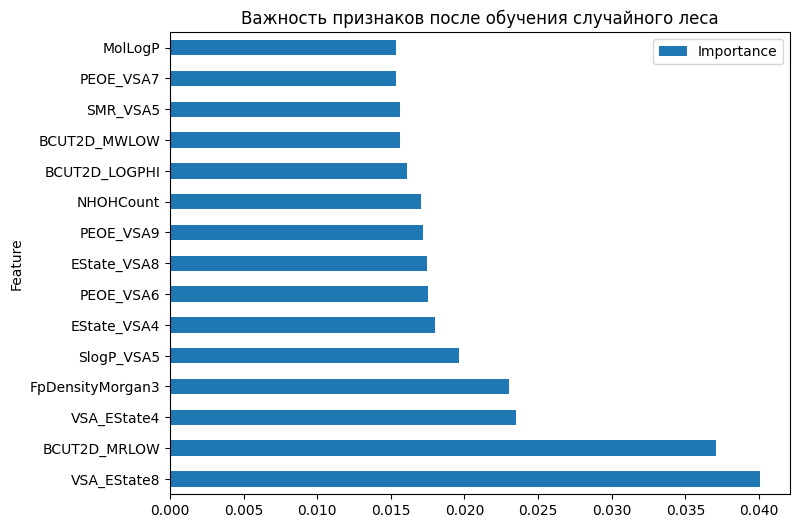

In [5]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)

Анализ важности признаков RandomForestClassifier для классификации IC50 показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные, топологические и физико-химические свойства молекул. 

Среди наиболее значимых признаков модель выделила VSA_EState8, BCUT2D_MRLOW, VSA_EState4, FpDensityMorgan3, SlogP_VSA5, а также ряд PEOE_VSA- и BCUT2D-дескрипторов. Это указывает на важную роль распределения электронной плотности, липофильности и структурных особенностей молекулы в определении уровня биологической активности соединений.

Высокая важность дескрипторов MolLogP, NHOHCount и FpDensityMorgan3 также свидетельствует о значительном влиянии гидрофобности, наличия функциональных групп и плотности молекулярных фрагментов на принадлежность соединений к различным классам активности IC50.

Полученные результаты подтверждают, что классификация IC50 определяется совокупностью топологических, электронных и физико-химических характеристик молекул, а ансамблевые методы позволяют эффективно выявлять наиболее информативные молекулярные дескрипторы для решения QSAR-задачи.

In [18]:
# Логистическая регрессия для предсказания исходного IC50 > медианного значения на основе молекулярных дескрипторов
# параметры модели: L1-регуляризация, solver='liblinear', max_iter=10000, random_state=42

model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=10000,
    random_state=42
)

model_l1.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model_l1.predict(X_test)
y_prob = model_l1.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L1-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L1-регуляризацией:
              precision    recall  f1-score   support

           0       0.75      0.61      0.67       100
           1       0.67      0.80      0.73       100

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200

Матрица ошибок:
[[61 39]
 [20 80]]
Точность модели: 0.70
ROC AUC модели: 0.76


In [20]:
# Логистическая регрессия для предсказания исходного IC50 > медианного значения на основе молекулярных дескрипторов
# параметры модели: L2-регуляризация, solver='liblinear', max_iter=50000, random_state=42

# cоздание и обучение модели
model_l2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=50000,
    random_state=42
)

model_l2.fit(X_train, y_train)

# предсказывание на тестовой выборке
y_pred = model_l2.predict(X_test)
y_prob = model_l2.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L2-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L2-регуляризацией:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.50      1.00      0.67       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200

Матрица ошибок:
[[  0 100]
 [  0 100]]
Точность модели: 0.50
ROC AUC модели: 0.47


c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ekaterina\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

##### Вывод:

В отличие от L1-регуляризации(Accuracy ≈ 0.70, ROC-AUC ≈ 0.76), модель LogisticRegression с L2-регуляризацией показала крайне низкое качество классификации (Accuracy ≈ 0.50, ROC-AUC ≈ 0.47) и фактически предсказывала только один класс. 

Полученные результаты свидетельствуют о том, что для данной QSAR-задачи использование L2-регуляризации оказалось недостаточно эффективным в условиях высокой размерности и мультиколлинеарности молекулярных дескрипторов. Напротив, L1-регуляризация позволила автоматически выполнить отбор признаков и уменьшить влияние избыточных коррелированных дескрипторов, что улучшило качество классификации. 

Однако модели логистической регрессии уступили ансамблевым методам на основе случайного леса, что указывает на наличие сложных нелинейных зависимостей между молекулярными дескрипторами и биологической активностью соединений.

In [21]:
# CatBoost Classifier для предсказания исходного IC50 > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации CatBoost:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации CatBoost:
              precision    recall  f1-score   support

           0       0.72      0.70      0.71       100
           1       0.71      0.73      0.72       100

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200

Матрица ошибок:
[[70 30]
 [27 73]]
Точность модели: 0.71
ROC AUC модели: 0.79


##### Вывод:
 
Модель CatBoostClassifier показала высокое качество классификации IC50 (Accuracy ≈ 0.71, ROC-AUC ≈ 0.79) и обеспечила достаточно сбалансированное распознавание обоих классов. По сравнению с линейными моделями и одиночным деревом решений CatBoostClassifier лучше справился с выявлением сложных нелинейных зависимостей между молекулярными дескрипторами и уровнем биологической активности соединений.

Матрица ошибок и значения precision, recall и F1-score свидетельствуют о достаточно устойчивом разделении классов без выраженного смещения в сторону одного из них. 
Высокое значение ROC-AUC указывает на хорошую способность модели ранжировать соединения по вероятности принадлежности к различным классам активности, что особенно важно для QSAR-задач классификации.

Полученные результаты подтверждают эффективность boosting-моделей для анализа высокоразмерных молекулярных дескрипторов и выявления сложных закономерностей между структурой молекул и их биологической активностью.

<Axes: title={'center': 'Важность признаков после обучения CatBoost'}, ylabel='Feature'>

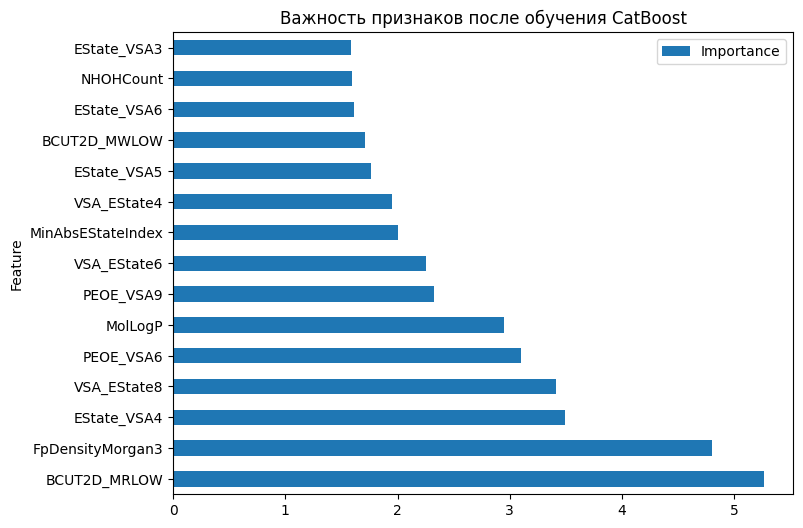

In [22]:
# визуализация важности признаков после обучения CatBoost
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения CatBoost'
)

Анализ важности признаков CatBoostClassifier для классификации IC50 показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные, топологические и физико-химические свойства молекул.

Среди наиболее значимых признаков модель выделила BCUT2D_MRLOW, FpDensityMorgan3, EState_VSA4, VSA_EState8, PEOE_VSA6 и MolLogP. Это указывает на важную роль распределения электронной плотности, липофильности, топологических особенностей и структуры молекулярных фрагментов в определении уровня биологической активности соединений.

Высокая важность дескрипторов PEOE_VSA9, VSA_EState6, MinAbsEStateIndex и NHOHCount также свидетельствует о значительном влиянии электронных характеристик, наличия функциональных групп и распределения поверхностных свойств молекулы на принадлежность соединений к различным классам активности IC50.

Полученные результаты хорошо согласуются с выводами моделей RandomForestClassifier и логистической регрессии, подтверждая устойчивую значимость электронных, топологических и физико-химических дескрипторов для решения QSAR-задачи классификации IC50.

In [23]:
# SVM Classifier  для предсказания исходного IC50 > медианного значения на основе молекулярных дескрипторов

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.decision_function(X_test)

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       100
           1       0.70      0.78      0.74       100

    accuracy                           0.72       200
   macro avg       0.73      0.73      0.72       200
weighted avg       0.73      0.72      0.72       200

Матрица ошибок:
[[67 33]
 [22 78]]
Точность модели: 0.72
ROC AUC модели: 0.76


In [24]:
# Настройка гиперпараметров для SVM Classifier с использованием GridSearchCV

# Создание пайплайна для стандартизации данных и обучения модели SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# Определение сетки гиперпараметров для поиска
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.1, 0.01, 0.001]
}

# Настройка GridSearchCV для поиска лучших гиперпараметров
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучение модели с использованием GridSearchCV
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Получение лучшей модели
best_svm = grid.best_estimator_

# Предсказывание на тестовой выборке с использованием лучшей модели
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 1, 'svc__gamma': 0.01}
Best CV ROC-AUC: 0.7911536787974682
Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.74      0.66      0.70       100
           1       0.69      0.77      0.73       100

    accuracy                           0.71       200
   macro avg       0.72      0.72      0.71       200
weighted avg       0.72      0.71      0.71       200

Матрица ошибок:
[[66 34]
 [23 77]]
Точность модели: 0.71
ROC AUC модели: 0.77


Для моделирования нелинейных зависимостей между молекулярными дескрипторами и принадлежностью соединений к различным классам была использована модель SVM (Support Vector Machine) с RBF-ядром. Поскольку метод опорных векторов чувствителен к масштабу признаков, перед обучением модели была выполнена стандартизация данных.

Базовая модель SVM показала хорошее качество классификации (Accuracy ≈ 0.72, ROC-AUC ≈ 0.76) и обеспечила достаточно сбалансированное распознавание обоих классов. 

Для повышения качества классификации SVM был выполнен подбор гиперпараметров (C и gamma) с использованием GridSearchCV и кросс-валидации (cv=5) по метрике ROC-AUC. В результате оптимизации наилучшими параметрами оказались C = 1 и gamma = 0.01, что позволило немного улучшить качество разделения классов (ROC-AUC ≈ 0.77).

Несмотря на то что итоговая accuracy практически не изменилась, увеличение ROC-AUC свидетельствует об улучшении способности модели ранжировать соединения по вероятности принадлежности к различным классам активности IC50. Полученные результаты подтверждают эффективность SVM с RBF-ядром для выявления сложных нелинейных закономерностей в высокоразмерных QSAR-данных.

#### Вывод:

В ходе работы были исследованы различные подходы к классификации соединений по уровню биологической активности IC50 на основе молекулярных дескрипторов. Были рассмотрены линейные и нелинейные модели машинного обучения, включая LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVM и CatBoostClassifier.

Линейные модели на основе логистической регрессии показали умеренное качество классификации. Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически выполнить отбор наиболее информативных молекулярных дескрипторов, что обеспечило более высокое качество классификации по сравнению с L2-регуляризацией.

Одиночное дерево решений продемонстрировало ограниченное качество классификации и склонность к переобучению. Применение ансамблевого метода RandomForestClassifier позволило повысить устойчивость модели и улучшить качество разделения классов за счёт более эффективного выявления нелинейных зависимостей между молекулярными дескрипторами и биологической активностью соединений.

Модель SVM с RBF-ядром также показала высокое качество классификации. Подбор гиперпараметров с использованием GridSearchCV позволил дополнительно улучшить качество разделения классов (ROC-AUC ≈ 0.77). Полученные результаты подтверждают эффективность kernel-методов для анализа высокоразмерных QSAR-данных и выявления сложных нелинейных закономерностей.

Наилучшее качество классификации среди исследованных моделей показал CatBoostClassifier (Accuracy ≈ 0.71, ROC-AUC ≈ 0.79), обеспечив наиболее устойчивое и сбалансированное распознавание обоих классов. Полученные результаты подтверждают высокую эффективность boosting-моделей при работе с большим количеством взаимосвязанных молекулярных дескрипторов.

Анализ важности признаков показал, что наибольший вклад в классификацию IC50 вносят дескрипторы, характеризующие электронные, топологические и физико-химические свойства молекул. Наиболее значимыми оказались дескрипторы семейств BCUT2D, VSA_EState, PEOE_VSA, а также показатели липофильности и структурной сложности молекулы.

Несмотря на использование различных методов машинного обучения, качество классификации оказалось умеренным, что указывает на высокую сложность QSAR-задачи и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.